# Gaussian and universality

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

In [9]:
# Parameters
M = 10000000  # Number of realizations (samples)
N = 30    # Number of iid variables per sample

# 1. Catan Throws (Sum of two dice, scaled up to N variables for CLT)
# Each 'realization' is the sum of N dice rolls
process_1 = np.sum(np.random.randint(1, 7, size=(M, N)), axis=1)

# 2. Uniform Distribution (Continuous)
process_2 = np.sum(np.random.uniform(0, 10, size=(M, N)), axis=1)

# 3. Exponential Distribution (Highly skewed)
process_3 = np.sum(np.random.exponential(scale=2.0, size=(M, N)), axis=1)

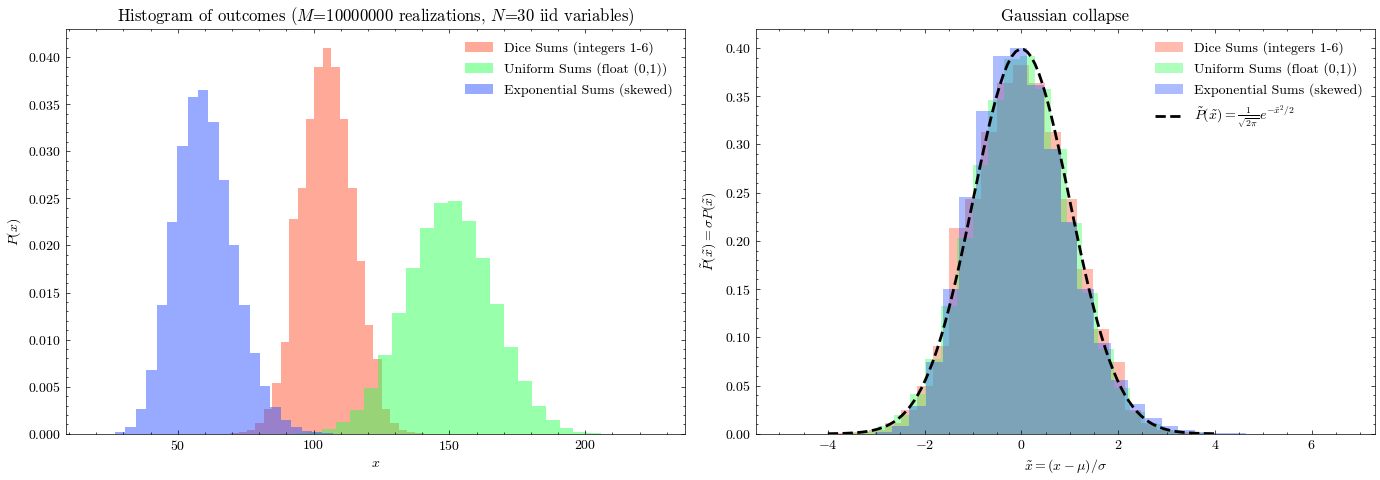

In [10]:
processes = [process_1, process_2, process_3]
labels = ['Dice Sums (integers 1-6)', 'Uniform Sums (float (0,1))', 'Exponential Sums (skewed)']
colors = ['#FF5733', '#33FF57', '#3357FF']

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Raw Outcomes (Different scales and means)
for data, label, color in zip(processes, labels, colors):
    ax1.hist(data, bins=30, alpha=0.5, label=label, color=color, density=True)
ax1.set_title(f"Histogram of outcomes ($M$={M} realizations, $N$={N} iid variables)")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$P(x)$")
ax1.legend()

# Subplot 2: Rescaled Variables (The Gaussian Collapse)
def rescale(data):
    mu = np.mean(data)
    sigma = np.std(data)
    # Applying: x_tilde = (x - mu) / sigma
    return (data - mu) / sigma

for data, label, color in zip(processes, labels, colors):
    rescaled_data = rescale(data)
    ax2.hist(rescaled_data, bins=30, alpha=0.4, label=label, color=color, density=True)

# Overlay the Standard Normal Curve
x_axis = np.linspace(-4, 4, 100)
gaussian = (1 / np.sqrt(2 * np.pi)) * np.exp(-x_axis**2 / 2)
ax2.plot(x_axis, gaussian, 'k--', linewidth=2, label=r'$\tilde{P}(\tilde{x})=\frac{1}{\sqrt{2\pi}} e^{-\tilde{x}^2/2}$')

ax2.set_title("Gaussian collapse")
ax2.set_xlabel(r"$\tilde{x} = (x - \mu) / \sigma$")
ax2.set_ylabel(r"$\tilde{P}(\tilde{x}) = \sigma P(\tilde{x})$")
ax2.legend()

plt.tight_layout()
plt.show()